In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 25
day = 24

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

25 24
optimal travel lag is 6.856856856856858 cm based on kde of travel at max spatial information
optimal travel lag is 6.856856856856858 cm
there are 39 non_grid and non_spatial_cells
there are 24 grid_cells
there are 33 non grid spatial cells
there are 6 non spatial cells
there are 6 speed cells
there are 69 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'PAR' 'VISpl5']
unique brain regions ['ENTm1' 'ENTm2' 'PAR' 'VISp5' 'VISpl5']
there are 43 MEC cells
there are 8 PARA cells
there are 0 PRE cells
there are 18 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 69 all cells
None
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 26.056554362780552
Not merging labels 0 and 2 with distance 15.404161697700657
Not merging l

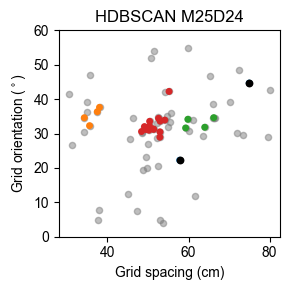

for module 0, there are 4 cells with average spacing 36.35747355941553
for module 1, there are 4 cells with average spacing 62.324193394413754
for module 2, there are 14 cells with average spacing 51.540367833089405
module 0 contains cells from ['VISpl5']
module 2 contains cells from ['ENTm2' 'VISpl5']
module 1 contains cells from ['ENTm1' 'ENTm2']
25 24
for module 0, there are 4 cells
for module 2, there are 14 cells
for module 1, there are 4 cells
plotting vr rate maps using cluster_ids [146, 147, 152, 153, 160, 162, 167, 172, 179, 180, 181, 182, 187, 240]


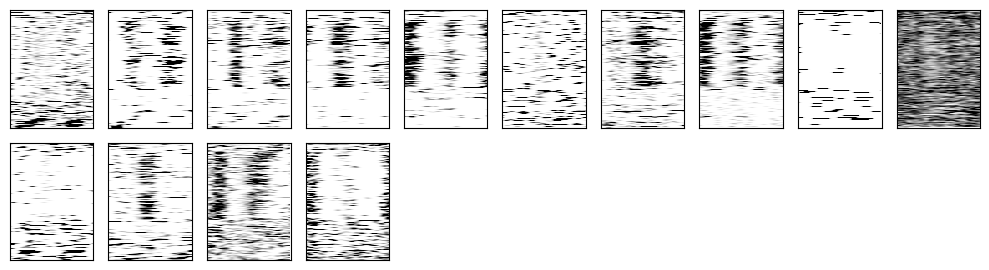

plotting vr rate maps using cluster_ids [236, 243, 244, 257]


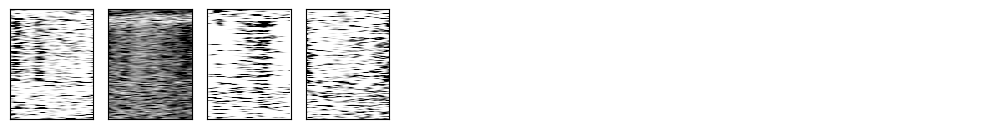

plotting vr rate maps using cluster_ids [112, 128, 130, 135]


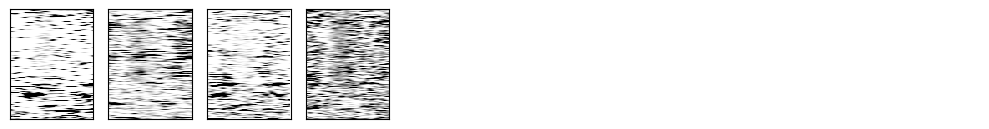

plotting vr rate maps using cluster_ids [113, 115, 117, 119, 120, 124, 125, 133, 144, 149, 151, 165, 170, 174, 190, 194, 196, 206, 207, 210, 216, 221, 224, 231, 237, 246, 247, 248, 249, 253, 255, 267, 280]


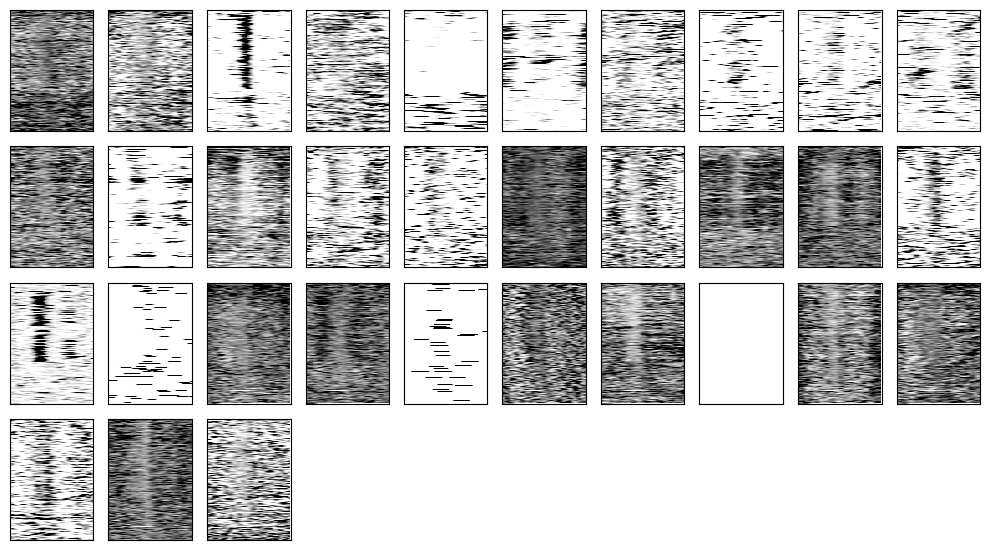

plotting vr rate maps using cluster_ids [97, 159, 161, 192, 245, 293]


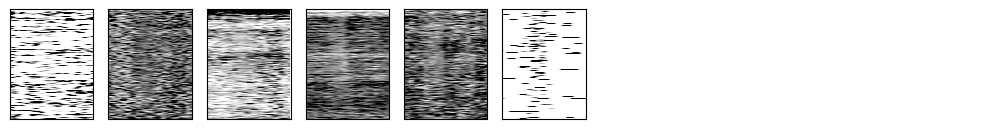

plotting vr rate maps using cluster_ids [112, 128, 130, 135, 146, 147, 152, 153, 155, 160, 162, 167, 172, 179, 180, 181, 182, 187, 204, 236, 240, 243, 244, 257]


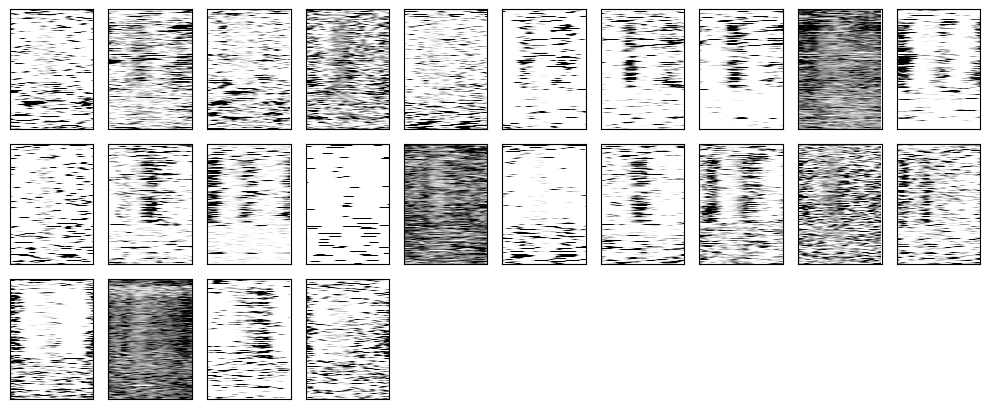

plotting vr rate maps using cluster_ids [102, 122, 148, 169, 258, 265]


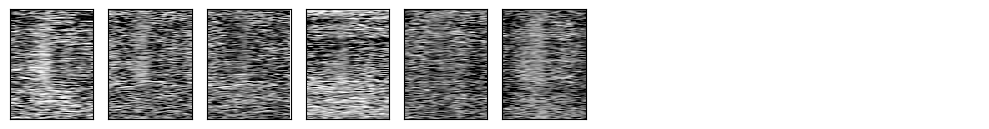

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)

g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)


In [4]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation

In [5]:
annotation_colors = get_annotation_colors_2D(annotations)

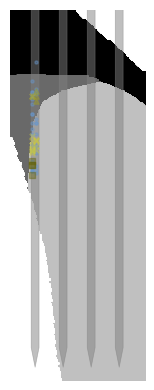

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.4, s=5)
ax.scatter(ns.probe_x.values, ns.probe_y.values, marker='o', color="#6c6c6c", alpha=0.4, s=5)

markers = ['x','^', 's']
colors=["#c04744", "#B6632F", "#c09744"]
for i, cluster_ids in enumerate(g_m_cluster_ids):
    gc_m = gcs[np.isin(gcs.cluster_id, cluster_ids)]
    ax.scatter(gc_m.probe_x.values, gc_m.probe_y.values, marker=markers[i], color=colors[i], alpha=0.4, s=15)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [7]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)

last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

plot a grid cell

In [8]:
test_grid_cell_id = 172  # the grid cell we will use to test the model
predictor_co_modular_grid_cell_id = 187  # a co modular grid cell
predictor_non_co_modular_grid_cell_id = 236 # a non co modular grid cell
predictor_ngs_cell_id = 174  # a non grid spatial cell

print(f'Grid cell id: {test_grid_cell_id}')
print(f'Co-modular grid cell id: {predictor_co_modular_grid_cell_id}')
print(f'Non co-modular grid cell id: {predictor_non_co_modular_grid_cell_id}')
print(f'Non grid spatial cell id: {predictor_ngs_cell_id}') 

Grid cell id: 172
Co-modular grid cell id: 187
Non co-modular grid cell id: 236
Non grid spatial cell id: 174


plot a reference grid cell


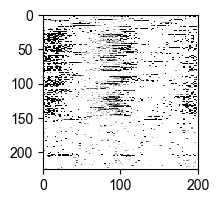

plot a co modular grid cell


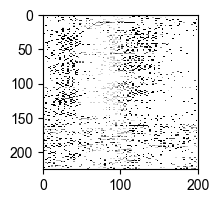

plot a non co modular grid cell


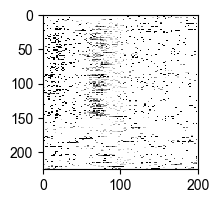

plot a ngs cell


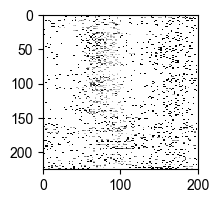

In [9]:
print('plot a reference grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[test_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()
print('plot a co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a non co modular grid cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_non_co_modular_grid_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

print('plot a ngs cell')
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(2, 2), squeeze=False)
plot_firing_rate_map(ax[0,0], zscore(tcs[predictor_ngs_cell_id]), bs=bs, tl=tl, p=95)
plt.show()

In [10]:
co_modular_grid_cells_minus_test = gcs[gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()
co_modular_grid_cells_minus_test = co_modular_grid_cells_minus_test[co_modular_grid_cells_minus_test.cluster_id != test_grid_cell_id]  # remove the test cell
non_co_modular_grid_cells = gcs[~gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()

cov_tcs_time_cm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in co_modular_grid_cells_minus_test.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ncm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in non_co_modular_grid_cells.cluster_id.values if cluster_id in tcs_time}
cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

In [ ]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

y = np.array(tcs_time[test_grid_cell_id])
y_smoothed = gaussian_filter_nan(y, sigma=3) # smooth the target variable

X  = np.stack([pos_in_time]).T # pos in time

Xcmg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # co modular grid cell
Xncmg1 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # non co modular grid cell
Xngs1 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell

Xcmgmax = np.column_stack((np.vstack(list(cov_tcs_time_cm_grids.values())).T)).T # comodular grid cells  
Xncmgmax = np.column_stack((np.vstack(list(cov_tcs_time_ncm_grids.values())).T)).T # non co modular grid cells         
Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T # non grid spatial cells        

Xpos_cmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T # cm grid cell + pos in time
Xpos_ncmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T # ncm grid cell + pos in time
Xpos_ngs1 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T # ngs cell 2 + pos in time

Xpos_cmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_cm_grids.values())).T)) # co mod grid cells + pos in time     
Xpos_ncmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ncm_grids.values())).T)) # non co mod grid cells + pos in time     
Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T)) # non grid spatial cells + pos in time      


Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)

Y_hat_cmg1, pR2_cv_cmg1 = xgb_history.fit_cv(Xcmg1, y, verbose = 0, continuous_folds = True)
Y_hat_ncmg1, pR2_cv_ncmg1 = xgb_history.fit_cv(Xncmg1, y, verbose = 0, continuous_folds = True)
Y_hat_ngs1, pR2_cv_ngs1 = xgb_history.fit_cv(Xngs1, y, verbose = 0, continuous_folds = True)

Y_hat_cmgmax, pR2_cv_cmgmax = xgb_history.fit_cv(Xcmgmax, y, verbose = 0, continuous_folds = True)
Y_hat_ncmgmax, pR2_cv_ncmgmax = xgb_history.fit_cv(Xncmgmax, y, verbose = 0, continuous_folds = True)
Y_hat_ngsmax, pR2_cv_ngsmax = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)

Y_hat_pos_cmg1, pR2_cv_pos_cmg1 = xgb_history.fit_cv(Xpos_cmg1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ncmg1, pR2_cv_pos_ncmg1 = xgb_history.fit_cv(Xpos_ncmg1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs1, pR2_cv_pos_ngs1 = xgb_history.fit_cv(Xpos_ngs1, y, verbose = 0, continuous_folds = True)

Y_hat_pos_cmgmax, pR2_cv_pos_cmgmax = xgb_history.fit_cv(Xpos_cmgmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ncmgmax, pR2_cv_pos_ncmgmax = xgb_history.fit_cv(Xpos_ncmgmax, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngsmax, pR2_cv_pos_ngsmax = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)


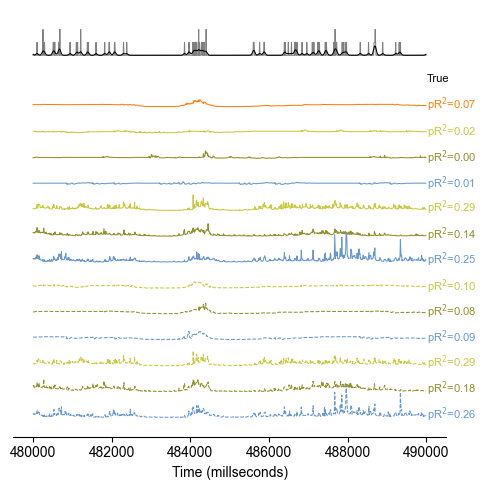

In [33]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=48000
end=start+1000
sf = -2 # scale factor for the y-axis
lw = 0.75
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-1), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-1), label='True', color='black', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p))[start:end]*time_bs, Y_hat_p[start:end]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_cmg1))[start:end]*time_bs, Y_hat_cmg1[start:end]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_ncmg1))[start:end]*time_bs, Y_hat_ncmg1[start:end]*sf + (offset*3), color='#92902C', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_ngs1))[start:end]*time_bs, Y_hat_ngs1[start:end]*sf + (offset*4), color='#6897CD', linewidth=lw, label='NGS cell 2')
ax.plot(np.arange(len(Y_hat_cmgmax))[start:end]*time_bs, Y_hat_cmgmax[start:end]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ncmgmax))[start:end]*time_bs, Y_hat_ncmgmax[start:end]*sf + (offset*6), color='#92902C', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ngsmax))[start:end]*time_bs, Y_hat_ngsmax[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='NGS cells')
ax.plot(np.arange(len(Y_hat_pos_cmg1))[start:end]*time_bs, Y_hat_pos_cmg1[start:end]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
ax.plot(np.arange(len(Y_hat_pos_ncmg1))[start:end]*time_bs, Y_hat_pos_ncmg1[start:end]*sf + (offset*9), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
ax.plot(np.arange(len(Y_hat_pos_ngs1))[start:end]*time_bs, Y_hat_pos_ngs1[start:end]*sf + (offset*10), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
ax.plot(np.arange(len(Y_hat_pos_cmgmax))[start:end]*time_bs, Y_hat_pos_cmgmax[start:end]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
ax.plot(np.arange(len(Y_hat_pos_ncmgmax))[start:end]*time_bs, Y_hat_pos_ncmgmax[start:end]*sf + (offset*12), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cells')
ax.plot(np.arange(len(Y_hat_pos_ngsmax))[start:end]*time_bs, Y_hat_pos_ngsmax[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript
ax.text(end*time_bs + 10, np.mean(y[start:end]*sf), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:orange')
ax.text(end*time_bs + 10, np.mean(Y_hat_cmg1[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ncmg1[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs1[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_cmgmax[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_ncmgmax[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngsmax[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cmg1[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ncmg1[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs1[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_cmgmax[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ncmgmax[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngsmax[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')

#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [13]:
labels_in_time = get_task_anchored_labels_in_time(mouse,day,cluster_ids_for_spectrogram=g_m_cluster_ids[0])

Identified 1 candidate modules


In [14]:
labels_in_time.shape

(185771,)

In [15]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import imageio

frames = []
gif_path = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/session_spectrogram.gif'

window_size = 1000
step_size = 100  # adjust for smoothness/speed
sf = -2
offset = 2
lw = 0.75

for s in range(0, len(y) - window_size, step_size):
    e = s + window_size
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(np.arange(len(y))[s:e]*time_bs, y[s:e]*sf, label='True', color='black', linewidth=lw)
    ax.plot(np.arange(len(Y_hat_p))[s:e]*time_bs, Y_hat_p[s:e]*sf + offset, color='tab:orange', linewidth=lw, label='Position')
    ax.plot(np.arange(len(Y_hat_cmg1))[s:e]*time_bs, Y_hat_cmg1[s:e]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ncmg1))[s:e]*time_bs, Y_hat_ncmg1[s:e]*sf + (offset*3), color='#92902C', linewidth=lw, label='Grid cell 10')
    ax.plot(np.arange(len(Y_hat_ngs1))[s:e]*time_bs, Y_hat_ngs1[s:e]*sf + (offset*4), color='#6897CD', linewidth=lw, label='NGS cell 2')
    ax.plot(np.arange(len(Y_hat_cmgmax))[s:e]*time_bs, Y_hat_cmgmax[s:e]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ncmgmax))[s:e]*time_bs, Y_hat_ncmgmax[s:e]*sf + (offset*6), color='#92902C', linewidth=lw, label='Grid cells')
    ax.plot(np.arange(len(Y_hat_ngsmax))[s:e]*time_bs, Y_hat_ngsmax[s:e]*sf + (offset*7), color='#6897CD', linewidth=lw, label='NGS cells')
    ax.plot(np.arange(len(Y_hat_pos_cmg1))[s:e]*time_bs, Y_hat_pos_cmg1[s:e]*sf + (offset*8), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ncmg1))[s:e]*time_bs, Y_hat_pos_ncmg1[s:e]*sf + (offset*9), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cell 10')
    ax.plot(np.arange(len(Y_hat_pos_ngs1))[s:e]*time_bs, Y_hat_pos_ngs1[s:e]*sf + (offset*10), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cell 2')
    ax.plot(np.arange(len(Y_hat_pos_cmgmax))[s:e]*time_bs, Y_hat_pos_cmgmax[s:e]*sf + (offset*11), color='#CAC841', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ncmgmax))[s:e]*time_bs, Y_hat_pos_ncmgmax[s:e]*sf + (offset*12), color='#92902C', linewidth=lw, linestyle='--', label='Position + Grid cells')
    ax.plot(np.arange(len(Y_hat_pos_ngsmax))[s:e]*time_bs, Y_hat_pos_ngsmax[s:e]*sf + (offset*13), color='#6897CD', linewidth=lw, linestyle='--', label='Position + NGS cells')
    ax.set_xlabel('Time (millseconds)')

    # Scatter for labels_in_time
    label_vals = labels_in_time[s:e]
    cmap = cm.get_cmap('cool')
    scatter_y = np.full_like(label_vals, np.max(y[s:e]*sf) - 6)
    ax.scatter(np.arange(len(y))[s:e]*time_bs, scatter_y, c=label_vals, cmap=cmap, s=10, vmin=0, vmax=1, marker='|', linewidths=2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.invert_yaxis()
    plt.tight_layout()

    # Save frame to buffer using fig.canvas.buffer_rgba()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())
    frames.append(frame)
    plt.close(fig)

# Save as GIF
imageio.mimsave(gif_path, frames, duration=0.15)
print(f"GIF saved to {gif_path}")

GIF saved to /Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_spectrograms/session_spectrogram.gif


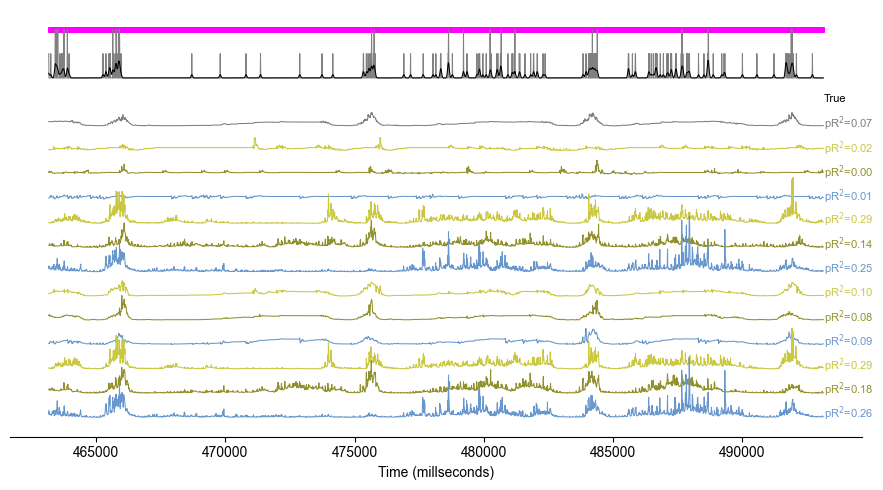

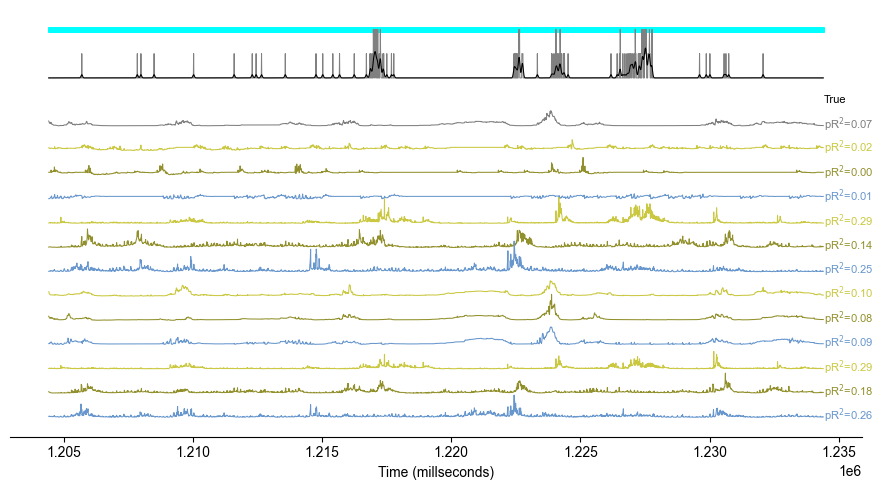

In [35]:
import matplotlib.cm as cm

pairs = [(48316-1500, 49316+500), (121441-500, 122441+1500)]
labels = ['task_anchored', 'task_independent']
window_size = 3000  # changed from 1000 to 2000
n_variations = 1
variation_range = 500

for (start, end), label in zip(pairs, labels):
    offsets = np.linspace(-variation_range, variation_range, n_variations, dtype=int)
    for v in offsets:
        s = start + v
        e = end + v
        # Ensure window size is 2000
        if s < 0 or e > len(y) or (e-s) != window_size:
            continue
        fig, ax = plt.subplots(figsize=(9, 5))  # wider plot
        offset = 2
        sf = -4
        true_sf = -2
        lw = 0.75

        # Plot traces
        ax.plot(np.arange(len(y))[s:e]*time_bs, y[s:e]*sf*0.5 + (offset*-1), label='True', color='grey', linewidth=lw)
        ax.plot(np.arange(len(y))[s:e]*time_bs, y_smoothed[s:e]*sf*0.5 + (offset*-1), label='True', color='black', linewidth=lw)
        ax.plot(np.arange(s, e)*time_bs, Y_hat_p[s:e]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_cmg1[s:e]*sf + (offset*2), color='#CAC841', linewidth=lw, label='Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ncmg1[s:e]*sf + (offset*3), color='#92902C', linewidth=lw, label='Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ngs1[s:e]*sf + (offset*4), color='#6897CD', linewidth=lw, label='NGS cell 2')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_cmgmax[s:e]*sf + (offset*5), color='#CAC841', linewidth=lw, label='Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ncmgmax[s:e]*sf + (offset*6), color='#92902C', linewidth=lw, label='Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_ngsmax[s:e]*sf + (offset*7), color='#6897CD', linewidth=lw, label='NGS cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_cmg1[s:e]*sf + (offset*8), color='#CAC841', linewidth=lw, label='Position + Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ncmg1[s:e]*sf + (offset*9), color='#92902C', linewidth=lw, label='Position + Grid cell 10')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ngs1[s:e]*sf + (offset*10), color='#6897CD', linewidth=lw, label='Position + NGS cell 2')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_cmgmax[s:e]*sf + (offset*11), color='#CAC841', linewidth=lw, label='Position + Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ncmgmax[s:e]*sf + (offset*12), color='#92902C', linewidth=lw, label='Position + Grid cells')
        ax.plot(np.arange(s, e)*time_bs, Y_hat_pos_ngsmax[s:e]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Position + NGS cells')
        ax.set_xlabel('Time (millseconds)')

        # Scatter for labels_in_time
        label_vals = labels_in_time[s:e]
        cmap = cm.get_cmap('cool')
        scatter_y = np.full_like(label_vals, np.max(y[s:e]*sf) - 6)
        ax.scatter(np.arange(s, e)*time_bs, scatter_y, c=label_vals, cmap=cmap, s=10, vmin=0, vmax=1, marker='|', linewidths=2)

        # Annotate mean pR² values with superscript
        ax.text(e*time_bs + 10, np.mean(y[s:e]*sf), 'True', va='center', fontsize=8, color='black')
        ax.text(e*time_bs + 10, np.mean(Y_hat_p[s:e]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:grey')
        ax.text(e*time_bs + 10, np.mean(Y_hat_cmg1[s:e]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ncmg1[s:e]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ngs1[s:e]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_cmgmax[s:e]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ncmgmax[s:e]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_ngsmax[s:e]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_cmg1[s:e]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmg1):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ncmg1[s:e]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmg1):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ngs1[s:e]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs1):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_cmgmax[s:e]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_cmgmax):.2f}', va='center', fontsize=8, color='#CAC841')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ncmgmax[s:e]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ncmgmax):.2f}', va='center', fontsize=8, color='#92902C')
        ax.text(e*time_bs + 10, np.mean(Y_hat_pos_ngsmax[s:e]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngsmax):.2f}', va='center', fontsize=8, color='#6897CD')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_prediction_{start}_{end}_v{v}_{label}.pdf', bbox_inches='tight')
        plt.show()

In [ ]:
figpath_rm = '/Users/harryclark/Desktop/M25D24'
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=gcs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_based_on_task_anchoring(mouse, day, cluster_ids=ngs.cluster_id.values, cluster_ids_for_spectrogram=g_m_cluster_ids[0], label='NGS', figpath=figpath_rm)

Identified 1 candidate modules
Identified 1 candidate modules


: 

In [ ]:
import matplotlib.pyplot as plt

# Model names and predictions
model_names = [
    'Position', 'Grid cell 10', 'Grid cell 10 (ncm)', 'NGS cell 2', 'Grid cells', 'Grid cells (ncm)', 'NGS cells',
    'Position + Grid cell 10', 'Position + Grid cell 10 (ncm)', 'Position + NGS cell 2',
    'Position + Grid cells', 'Position + Grid cells (ncm)', 'Position + NGS cells'
]
model_vars = [
    Y_hat_p, Y_hat_cmg1, Y_hat_ncmg1, Y_hat_ngs1, Y_hat_cmgmax, Y_hat_ncmgmax, Y_hat_ngsmax,
    Y_hat_pos_cmg1, Y_hat_pos_ncmg1, Y_hat_pos_ngs1,
    Y_hat_pos_cmgmax, Y_hat_pos_ncmgmax, Y_hat_pos_ngsmax
]

# Masks for labels_in_time
mask_0 = labels_in_time == 0
mask_1 = labels_in_time == 1

pseudoR2_0 = []
pseudoR2_1 = []
for yhat in model_vars:
    ynull_0 = np.mean(y[mask_0])
    ynull_1 = np.mean(y[mask_1])
    pseudoR2_0.append(poisson_pseudoR2(y[mask_0], yhat[mask_0], ynull_0))
    pseudoR2_1.append(poisson_pseudoR2(y[mask_1], yhat[mask_1], ynull_1))

# Horizontal bar plot with values
fig, ax2 = plt.subplots(figsize=(2, 6))
bar_width = 0.4
y_pos = np.arange(len(model_names))
colors = ['cyan', 'magenta']  # label=0: cyan, label=1: magenta

bars0 = ax2.barh(y_pos-bar_width/2, pseudoR2_0, bar_width, color=colors[0], label='label=0')
bars1 = ax2.barh(y_pos+bar_width/2, pseudoR2_1, bar_width, color=colors[1], label='label=1')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(model_names, fontsize=8)
ax2.set_yticklabels([], fontsize=8)

ax2.set_xlabel('pR²')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_task_anchored_versus_task_independent_singular_test_grid_cell_pR2.pdf', bbox_inches='tight')
plt.show()

I can now run the test now using each grid cell from the most abundant module. to get an average

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names for bar plot
model_names = [
    'Position', 'Grid cell 10', 'Grid cell 10 (ncm)', 'NGS cell 2', 'Grid cells', 'Grid cells (ncm)', 'NGS cells',
    'Position + Grid cell 10', 'Position + Grid cell 10 (ncm)', 'Position + NGS cell 2',
    'Position + Grid cells', 'Position + Grid cells (ncm)', 'Position + NGS cells'
]

pseudoR2_0_list = []
pseudoR2_1_list = []

for test_grid_cell_id in g_m_cluster_ids[0]:
    print(f'Testing grid cell ID: {test_grid_cell_id}')
    # --- predictors selection ---
    predictor_co_modular_grid_cell_id = g_m_cluster_ids[0][12]
    if test_grid_cell_id == predictor_co_modular_grid_cell_id:
        predictor_co_modular_grid_cell_id = g_m_cluster_ids[0][7]
    predictor_non_co_modular_grid_cell_id = g_m_cluster_ids[1][0]
    predictor_ngs_cell_id = ngs.cluster_id.values[13]

    co_modular_grid_cells_minus_test = gcs[gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()
    co_modular_grid_cells_minus_test = co_modular_grid_cells_minus_test[co_modular_grid_cells_minus_test.cluster_id != test_grid_cell_id]
    non_co_modular_grid_cells = gcs[~gcs.cluster_id.isin(g_m_cluster_ids[0])].copy()

    cov_tcs_time_cm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in co_modular_grid_cells_minus_test.cluster_id.values if cluster_id in tcs_time}
    cov_tcs_time_ncm_grids = {cluster_id: tcs_time[cluster_id] for cluster_id in non_co_modular_grid_cells.cluster_id.values if cluster_id in tcs_time}
    cov_tcs_time_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs.cluster_id.values if cluster_id in tcs_time}

    xgb_history = MLencoding(tunemodel = 'xgboost',
                             cov_history = True, spike_history=False,
                             window = time_bs,
                             n_filters = 5,
                             max_time = 1000)

    y = np.array(tcs_time[test_grid_cell_id])
    X  = np.stack([pos_in_time]).T
    Xcmg1 = np.stack([np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xncmg1 = np.stack([np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xngs1 = np.stack([np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xcmgmax = np.column_stack((np.vstack(list(cov_tcs_time_cm_grids.values())).T)).T
    Xncmgmax = np.column_stack((np.vstack(list(cov_tcs_time_ncm_grids.values())).T)).T
    Xngsmax = np.column_stack((np.vstack(list(cov_tcs_time_ngs.values())).T)).T

    Xpos_cmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_co_modular_grid_cell_id])]).T
    Xpos_ncmg1 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_co_modular_grid_cell_id])]).T
    Xpos_ngs1 = np.stack([pos_in_time, np.array(tcs_time[predictor_ngs_cell_id])]).T

    Xpos_cmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_cm_grids.values())).T))
    Xpos_ncmgmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ncm_grids.values())).T))
    Xpos_ngsmax = np.column_stack((pos_in_time, np.vstack(list(cov_tcs_time_ngs.values())).T))

    # --- Fit models ---
    Y_hat_p, _ = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
    Y_hat_cmg1, _ = xgb_history.fit_cv(Xcmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_ncmg1, _ = xgb_history.fit_cv(Xncmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_ngs1, _ = xgb_history.fit_cv(Xngs1, y, verbose = 0, continuous_folds = True)
    Y_hat_cmgmax, _ = xgb_history.fit_cv(Xcmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_ncmgmax, _ = xgb_history.fit_cv(Xncmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_ngsmax, _ = xgb_history.fit_cv(Xngsmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_cmg1, _ = xgb_history.fit_cv(Xpos_cmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ncmg1, _ = xgb_history.fit_cv(Xpos_ncmg1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ngs1, _ = xgb_history.fit_cv(Xpos_ngs1, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_cmgmax, _ = xgb_history.fit_cv(Xpos_cmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ncmgmax, _ = xgb_history.fit_cv(Xpos_ncmgmax, y, verbose = 0, continuous_folds = True)
    Y_hat_pos_ngsmax, _ = xgb_history.fit_cv(Xpos_ngsmax, y, verbose = 0, continuous_folds = True)

    model_vars = [
        Y_hat_p, Y_hat_cmg1, Y_hat_ncmg1, Y_hat_ngs1, Y_hat_cmgmax, Y_hat_ncmgmax, Y_hat_ngsmax,
        Y_hat_pos_cmg1, Y_hat_pos_ncmg1, Y_hat_pos_ngs1,
        Y_hat_pos_cmgmax, Y_hat_pos_ncmgmax, Y_hat_pos_ngsmax
    ]

    # --- Calculate pseudoR2 for each label ---
    mask_0 = labels_in_time == 0
    mask_1 = labels_in_time == 1
    pseudoR2_0 = []
    pseudoR2_1 = []
    for yhat in model_vars:
        ynull_0 = np.mean(y[mask_0])
        ynull_1 = np.mean(y[mask_1])
        pseudoR2_0.append(poisson_pseudoR2(y[mask_0], yhat[mask_0], ynull_0))
        pseudoR2_1.append(poisson_pseudoR2(y[mask_1], yhat[mask_1], ynull_1))
    pseudoR2_0_list.append(pseudoR2_0)
    pseudoR2_1_list.append(pseudoR2_1)

In [ ]:
# --- Average and SEM across grid cells ---
pseudoR2_0_avg = np.nanmean(pseudoR2_0_list, axis=0)
pseudoR2_1_avg = np.nanmean(pseudoR2_1_list, axis=0)
pseudoR2_0_sem = np.nanstd(pseudoR2_0_list, axis=0) / np.sqrt(len(pseudoR2_0_list))
pseudoR2_1_sem = np.nanstd(pseudoR2_1_list, axis=0) / np.sqrt(len(pseudoR2_1_list))

# --- Plot with error bars ---
fig, ax2 = plt.subplots(figsize=(2, 6))
bar_width = 0.4
y_pos = np.arange(len(model_names))
colors = ['cyan', 'magenta']

bars0 = ax2.barh(y_pos-bar_width/2, pseudoR2_0_avg, bar_width, xerr=pseudoR2_0_sem, color=colors[0], label='label=0', capsize=0)
bars1 = ax2.barh(y_pos+bar_width/2, pseudoR2_1_avg, bar_width, xerr=pseudoR2_1_sem, color=colors[1], label='label=1', capsize=0)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([], fontsize=8)
ax2.set_xlabel('pR²')
ax2.invert_yaxis()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_task_anchored_versus_task_independent_all_grid_cells_pR2.pdf', bbox_inches='tight')
plt.show()

appendix 1 hyperparameter search

In [ ]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


In [ ]:
hyperoptBest